In [1]:
%pip install ultralytics

In [2]:
import os

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import cv2

from ultralytics import YOLO
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, precision_score, recall_score, f1_score

In [6]:
def generate_circle_image(size=572, num_circles=20, min_radius=5, max_radius=50, border=92, noise_sigma=20):
    image = np.zeros((size, size, 3))
    mask = np.zeros((size, size), dtype=bool)

    background_color = np.random.uniform(0, 0.3, 3)
    image[:, :, :] = background_color

    for _ in range(num_circles):
        center_x = np.random.randint(border, size - border)
        center_y = np.random.randint(border, size - border)
        radius = np.random.randint(min_radius, max_radius)
        circle_color = np.random.uniform(0.5, 1.0, 3)

        y, x = np.ogrid[-center_x:size-center_x, -center_y:size-center_y]
        circle_mask = x*x + y*y <= radius*radius

        mask = np.logical_or(mask, circle_mask)

        for c in range(3):
            image[circle_mask, c] = circle_color[c]

    noise = np.random.normal(scale=noise_sigma/255, size=image.shape)
    image = image + noise
    image = np.clip(image, 0, 1)

    return image, mask.astype(np.float32)

def generate_dataset(num_samples, size=572, **kwargs):
    images = []
    masks = []

    for i in range(num_samples):
        img, msk = generate_circle_image(size=size, **kwargs)
        images.append(img)
        masks.append(msk)

        if (i + 1) % 100 == 0:
            print(f"Generated {i + 1}/{num_samples} images")

    return np.array(images), np.array(masks)

In [7]:
def visualize_sample(image, mask):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

    ax1.imshow(image)
    ax1.set_title('Original Image')
    ax1.axis('off')

    ax2.imshow(mask, cmap='gray')
    ax2.set_title('Mask')
    ax2.axis('off')

    overlay = image.copy()
    overlay[mask > 0.5] = [1, 0, 0]
    ax3.imshow(overlay)
    ax3.set_title('Overlay')
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

Генерация тестового датасета...


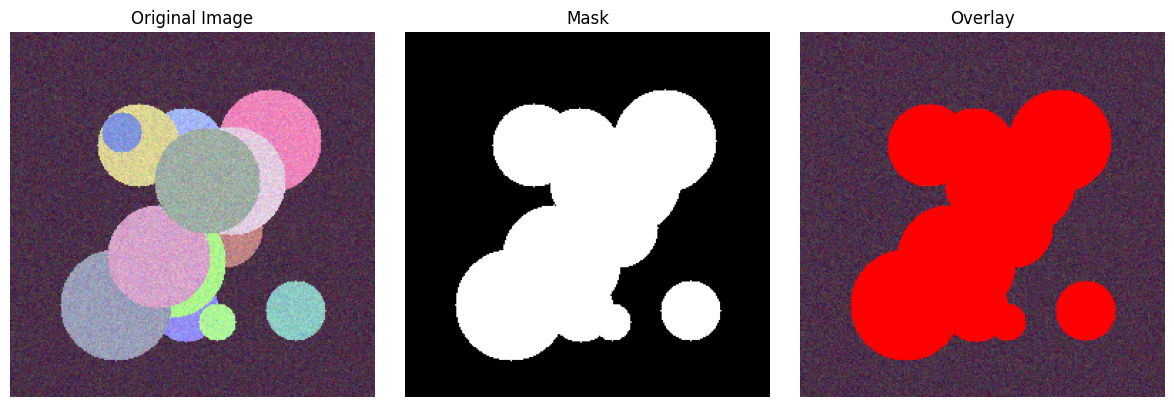

In [8]:
print("Генерация тестового датасета...")
images, masks = generate_dataset(
    num_samples=10,
    size=256,
    num_circles=15,
    min_radius=10,
    max_radius=40,
    border=50,
    noise_sigma=15
)

visualize_sample(images[0], masks[0])

# Датасет

In [9]:
def mask_to_yolo_polygons(mask, img_shape):
    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    yolo_annotations = []
    h, w = img_shape[:2]

    for contour in contours:
        if len(contour) < 3:
            continue

        epsilon = 0.001 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) < 3:
            approx = contour

        points = []
        for point in approx:
            x = point[0][0] / w
            y = point[0][1] / h
            points.extend([x, y])

        yolo_annotations.append(points)

    return yolo_annotations

def prepare_yolo_dataset(images, masks, output_dir="yolo_dataset", test_size=0.15, val_size=0.15):
    for split in ['train', 'val', 'test']:
        os.makedirs(f"{output_dir}/{split}/images", exist_ok=True)
        os.makedirs(f"{output_dir}/{split}/labels", exist_ok=True)

    indices = np.arange(len(images))
    train_val_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=42)
    val_relative = val_size / (1 - test_size)
    train_idx, val_idx = train_test_split(train_val_idx, test_size=val_relative, random_state=42)

    splits = {
        'train': train_idx,
        'val': val_idx,
        'test': test_idx
    }

    for split_name, split_indices in splits.items():
        for idx in split_indices:
            img = images[idx]
            mask = masks[idx]

            img_uint8 = (img * 255).astype(np.uint8)
            img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

            img_filename = f"circle_{idx:06d}.png"
            img_path = f"{output_dir}/{split_name}/images/{img_filename}"
            cv2.imwrite(img_path, img_bgr)

            polygons = mask_to_yolo_polygons(mask, img.shape)

            label_path = f"{output_dir}/{split_name}/labels/{img_filename.replace('.png', '.txt')}"
            with open(label_path, 'w') as f:
                for poly in polygons:
                    points_str = ' '.join([f"{coord:.6f}" for coord in poly])
                    f.write(f"0 {points_str}\n")

    yaml_content = f"""
path: {os.path.abspath(output_dir)}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['circle']
"""

    with open(f"{output_dir}/dataset.yaml", 'w') as f:
        f.write(yaml_content)

    print(f"Dataset saved to {output_dir}")
    print(f"Train: {len(train_idx)} images")
    print(f"Val: {len(val_idx)} images")
    print(f"Test: {len(test_idx)} images")

    return f"{output_dir}/dataset.yaml"


images, masks = generate_dataset(num_samples=500, size=512, num_circles=20)
data_yaml = prepare_yolo_dataset(images, masks, output_dir="circles_dataset")

Generated 100/500 images
Generated 200/500 images
Generated 300/500 images
Generated 400/500 images
Generated 500/500 images
Dataset saved to circles_dataset
Train: 350 images
Val: 75 images
Test: 75 images


# Сегментация с помощью YOLO

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [11]:
EPOCHS = 30
IMAGE_SIZE = 512
BATCH_SIZE = 8

In [12]:
model = YOLO('yolov8n-seg.pt')

results = model.train(
    data=data_yaml,
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=device,
    save=True,
    exist_ok=True,
    verbose=True,
    task="segment"
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=circles_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

In [13]:
def evaluate_yolo_segmentation(model, images, masks):
    iou_scores = []

    for i in range(len(images)):
        img_uint8 = (images[i] * 255).astype(np.uint8)
        img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

        results = model(img_bgr, imgsz=IMAGE_SIZE, verbose=False, retina_masks=True)

        pred_mask = np.zeros(images[i].shape[:2], dtype=np.uint8)

        if len(results) > 0 and results[0].masks is not None:
            for mask_tensor in results[0].masks.data:
                mask_np = mask_tensor.cpu().numpy()
                mask_binary = cv2.resize(mask_np, (images[i].shape[1], images[i].shape[0]))
                mask_binary = (mask_binary > 0.5).astype(np.uint8)
                pred_mask = np.logical_or(pred_mask, mask_binary).astype(np.uint8)

        gt_mask = masks[i].astype(np.uint8)
        iou = jaccard_score(gt_mask.flatten(), pred_mask.flatten(), average='binary')
        iou_scores.append(iou)

    print(f"Mean IoU: {np.mean(iou_scores):.4f}")
    return {'iou': iou_scores}

def visualize_yolo_predictions(model, images, masks, num_samples=5):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))

    for i in range(num_samples):
        img_uint8 = (images[i] * 255).astype(np.uint8)
        img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)

        results = model(img_bgr, imgsz=IMAGE_SIZE, verbose=False, retina_masks=True)

        pred_mask = np.zeros(images[i].shape[:2], dtype=np.uint8)
        if len(results) > 0 and results[0].masks is not None:
            for mask_tensor in results[0].masks.data:
                mask_np = mask_tensor.cpu().numpy()
                mask_binary = cv2.resize(mask_np, (images[i].shape[1], images[i].shape[0]))
                pred_mask = np.logical_or(pred_mask, (mask_binary > 0.5).astype(np.uint8))

        ax1 = axes[i, 0] if num_samples > 1 else axes[0]
        ax1.imshow(img_uint8)
        ax1.set_title('Original')
        ax1.axis('off')

        ax2 = axes[i, 1] if num_samples > 1 else axes[1]
        ax2.imshow(pred_mask, cmap='gray')
        ax2.set_title('Prediction Mask')
        ax2.axis('off')

        ax3 = axes[i, 2] if num_samples > 1 else axes[2]
        ax3.imshow(masks[i], cmap='gray')
        ax3.set_title('Ground Truth Mask')
        ax3.axis('off')

    plt.tight_layout()
    plt.show()

In [14]:
print("Evaluating model...")
metrics = evaluate_yolo_segmentation(model, images, masks)

print("Visualizing predictions...")
visualize_yolo_predictions(model, images, masks, num_samples=5)

Output hidden; open in https://colab.research.google.com to view.